# **PhC RCWA Simulation (S<sup>4</sup>) — Unified Notebook**
### Calculating angle-, energy-, and momentum-resolved reflection $\small{E(\vec{k})}$ for periodic and planar photonic structures, including polarization response. Powered by [$S^4$](https://web.stanford.edu/group/fan/S4/). Credit due to Victor Liu (Fan Group, Stanford Electrical Engineering Department, 2012).

#### This notebook version written by Ezra Bader (Menon Group / LaNMP, CCNY, May 2026) with help from Dr. Claude (Anthropic).

<img src="https://web.stanford.edu/group/fan/S4/_images/schem_640.png" alt="schematic" width="400" align="right" width="100" style="margin-right: 100px; border: 5px solid maroon;">

<span style="font-size:30px;">**Workflow:**

<span style="font-size:20px;">**1.** Imports

<span style="font-size:20px;">**2.** Lattice & layers

<span style="font-size:20px;">**3.** Configure parameters

<span style="font-size:20px;">**4.** Verify/plot unit cell, refractive index

<span style="font-size:20px;">**5.** Core S4 functions

<span style="font-size:20px;">**6.** Convergence and spot tests

<span style="font-size:20px;">**7.** Run studies or load data

<span style="font-size:17px;"> &emsp; 7.0.1 — Quick checks, run study 0 (reflection)

<span style="font-size:17px;"> &emsp; 7.1.1 — Run study 1 (E vs. k)

<span style="font-size:17px;"> &emsp; 7.2.1 — Run study 2 (kx, ky)

<span style="font-size:17px;"> &emsp; 7.3.1 — Run study 3 (mode calculation)

<span style="font-size:20px;">**8.** Plotting

### Under construction --

<span style="font-size:20px;">**??.** GUI

<span style="font-size:20px;">**??.** Polarization vortex analysis


-------------------
# **Requirements**
### All standard python libraries will import automatically. If a library is not found, you probably haven't installed it in your environment. If you are using a conda environment, for example, and \<library-name\> is not found, you'll run the following in your command line:

```bash
conda activate <your-env-name>
conda install <library-name>
```

### Slightly more complicated is S4, which should be built from the source code. Unix-like environment and C++ compiler required—on Windows, you'll have to use something like WSL (Windows Subsystem for Linux). Then in the terminal:

```bash
cd ~/your-project-folder
git clone https://github.com/victorliu/S4.git
```

### Nothing else is technically required, but [the authors recommend](https://web.stanford.edu/group/fan/S4/install.html) certain additional packages. Once you've flagged these in your Makefile:

```bash
make lib
make S4_pyext
```

# **1. Imports**

In [62]:
import S4           # NOTE: Your python environment must have a valid S4 installation
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod
import threading
import time, warnings, itertools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import interp1d, griddata
from pathlib import Path
from joblib import Parallel, delayed
import re as _re
from datetime import datetime as _dt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from scipy.interpolate import griddata
import tkinter as tk
from tkinter import filedialog
import tempfile
import os
import shutil
import importlib
from dataclasses import dataclass, field
warnings.filterwarnings('ignore')

import rcwa_utils as ru # NOTE: Imports all the necessary helper functions to run this notebook.
importlib.reload(ru)

MATERIALS = ru.load_material_library()

Material library loaded. Currently supported materials:
Air, Si, SiO2, TiO2, SiN, CrSBr, MoOCl2, ReS2, LC


# **Layers**

For each layer specify a <span style="color:#9CDCFE">**MATERIAL**</span> and <span style="color:#9CDCFE">**THICKNESS**</span> (nm). Lattice constant will be set in the next cell.

Optional arguments:

<span style="color:#9CDCFE">**PATTERN**</span>  — Currently supported: 'hole', 'pillar', 'cuboids'.

<span style="color:#9CDCFE">**ROT (°)**</span>      — Rotates permittivity tensor $\bm{\epsilon_{ij}}$ about $\bm{\hat{z}}$. 

<span style="color:#9CDCFE">**TILT (°)**</span>     — Tilts $\bm{\epsilon_{ij}}$ towards $\bm{\hat{z}}$.
```python
# EXAMPALE CALLS: 

MY_LAYERS1 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('SiO2',   50,     pattern='hole', ff=0.5),
    ru.Layer('CrSBr',  70,     pattern='hole', ff=0.5, layer_rot=45),
    ru.Layer('Air',    500,    pattern=None)
]

MY_LAYERS2 = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('ReS2',   90,     pattern='cuboids', w0=250, alpha=0.6),
    ru.Layer('Air',    500,    pattern=None)
]
```

In [63]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║       LAYERS  (top to bottom; pick material, thickness in nm)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# NOTE: Stack is built top down, where the first layer starts at z=0 and ends at z=|layer_thickness|.
#       The "transmission" side will be the LAST layer in the following list.
#       Since RCWA is all plane waves, the actual orientation of your stack
#       shouldn't matter UNLESS your materials break reciprocity! Then you can no longer safely
#       exchange source & detector.

MY_LAYERS = [
    ru.Layer('Air',    500,    pattern=None),
    ru.Layer('SiO2',   50,     pattern='hole', ff=0.5),
    ru.Layer('CrSBr',  70,     pattern='hole', ff=0.5, layer_rot = 45),
    ru.Layer('SiO2',   100,    pattern=None),
    ru.Layer('Air',    500,    pattern=None)
]

ru.check_layers(layers=MY_LAYERS)

		material	thickness (nm)		pattern			rot (°)		tilt (°)
---------------------------------------------------------------------------------------------------------
layer 0:	Air		500			None			None		None
layer 1:	SiO2		50			hole, ff=0.5		None		None
layer 2:	CrSBr		70			hole, ff=0.5		45		None
layer 3:	SiO2		100			None			None		None
layer 4:	Air		500			None			None		None


# **3. Configure Parameters**

In [64]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    SWEEP PARAMETERS                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

conf = ru.RCWAConfig(
    layers = MY_LAYERS,
    lattice_const = 500.0,
    lam_start = 885.0,
    lam_stop = 1033.0,
    lam_step = 1.0,
    n_basis = 100,
    n_jobs = 8,
    global_rot = None,  # Global index tensor rotation around ẑ
    global_tilt = None, # Global index tensor tilt out of xy plane towards ẑ
    # save_to='default',
    save_to = '/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output',

    # Defining study 1, E vs. k
    study1 = ru.Study1Config(
        elev_max = 35.0,
        elev_n = 70,
        azim_vals = [0.0, 90.0]
    ),

    # Defining study 2, kx vs. ky
    study2 = ru.Study2Config(
        elev_max = 40.0,
        elev_n = 40,
        azim_n_max = 180,
        azim_n_min = 45
    )
)

conf.verify_config()

		material	thickness (nm)		pattern			rot (°)		tilt (°)
---------------------------------------------------------------------------------------------------------
layer 0:	Air		500			None			None		None
layer 1:	SiO2		50			hole, ff=0.5		None		None
layer 2:	CrSBr		70			hole, ff=0.5		45		None
layer 3:	SiO2		100			None			None		None
layer 4:	Air		500			None			None		None

Wavelengths: 885–1033 nm (149 pts)
Study 1: 70 elev × 2 azim = 140 pairs
Study 2: 3881 (azim, elev) pairs
Workers: 8  |  N_BASIS: 100

Output directory: /Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output


# **4. Unit Cell and Refractive Index Plots**

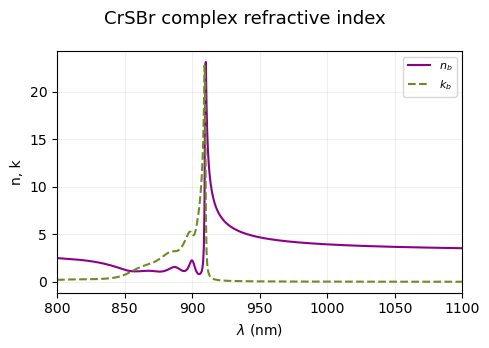

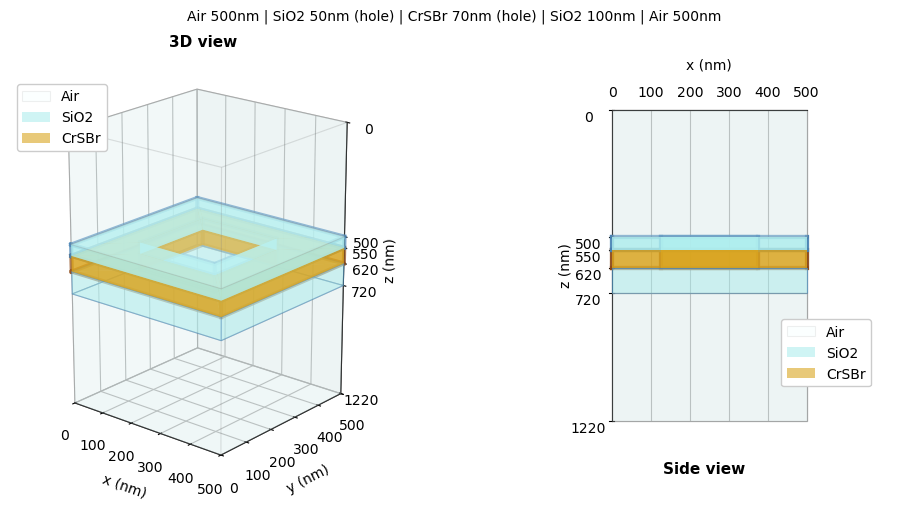

In [33]:
MATERIAL_COLORS = ru.get_material_colors()

# indexplot = ru.plot_refractive_index(conf,layers=None,materials=None,lam_min=None,lam_max=None,n_pts=600)
indexplot = ru.plot_refractive_index(conf, lam_min = 800, lam_max= 1100)
unitcellplot = ru.plot_unit_cell(conf, save_fig = False)

# **5. Core S4 Functions**

In [65]:
importlib.reload(ru) # For development, reloads source code
from rcwa_utils import (
    build_simulation, 
    update_simulation_materials, 
    sp_basis, 
    get_z_sample, 
    get_jones_matrices, 
    jones_to_circular, 
    compute_observables
)

# **6. Convergence tests**

### **6.1** Test definitions

In [66]:
importlib.reload(ru) # For development, reloads source code
from rcwa_utils import (
    convergence_test,
    convergence_test_phase,
    scan_wavelengths,
    verify_energy_conservation
)

### **6.2** Run tests

In [56]:
convergence_test(conf, basis_vals=(25, 49, 81, 100))
convergence_test_phase(conf, basis_vals=(25, 49, 81, 100))
# scan_wavelengths(conf)
verify_energy_conservation(conf)

%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Convergence test: λ=959 nm  elev=5.0°  azim=0°  rot=0°  tilt=0°
Stack: Layer(Air, 500nm) | Layer(SiO2, 50nm, hole, ff=0.5) | Layer(CrSBr, 70nm, hole, ff=0.5, rot=45°) | Layer(SiO2, 100nm) | Layer(Air, 500nm)
|   NumBasis        T_ss        T_pp     |dT_ss|    time(ms)
|         25     0.08794     0.09531         nan        62.9
|         49     0.11700     0.12381     0.02905       296.3
|         81     0.13566     0.14248     0.01866       981.2
|        100     0.14076     0.14751     0.00511      1667.6
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Phase convergence: λ=959 nm  elev=5.0°  azim=0°    rot=0°    tilt=0°
|   NumBasis      |t_ss|    phase_ss (deg)          CD    time(ms)
|         25     0.37518          -164.964    -0.00006      1513.8
|         49     0.37518          -164.964    -0.00006      1527.7
|         81     0.37518          -

# **7. Run Studies or Load Data**

### **7.0.1 Quick Tests & Study 0 (reflection)**

In [67]:
importlib.reload(ru)
quick_test1 = ru.quick_test_study1(conf)


Study 1: 8 pairs  |  8 workers
  P=500 nm  |  Air 500nm  |  SiO2 50nm (hole ff=0.5)  |  CrSBr 70nm (hole ff=0.5)  |  SiO2 100nm  |  Air 500nm
  Study 1 [1/8  12%]  0.0 min elapsed,  ETC: 0.2 min  (1.7 s/task)
  Study 1 [2/8  25%]  0.0 min elapsed,  ETC: 0.1 min  (0.9 s/task)
  Study 1 [3/8  38%]  0.0 min elapsed,  ETC: 0.0 min  (0.6 s/task)
  Study 1 [4/8  50%]  0.0 min elapsed,  ETC: 0.0 min  (0.4 s/task)
  Study 1 [5/8  62%]  0.0 min elapsed,  ETC: 0.0 min  (0.4 s/task)
  Study 1 [6/8  75%]  0.0 min elapsed,  ETC: 0.0 min  (0.3 s/task)
  Study 1 [7/8  88%]  0.0 min elapsed,  ETC: 0.0 min  (0.3 s/task)
  Study 1 [8/8  100%]  0.0 min elapsed,  ETC: 0.0 min  (0.2 s/task)
%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--%--
Study 1 done in 0.0 min
/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output
|
|
V
Config saved as study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_rot45_SiO2-100nm_rot00_nb25_v5.json.
Data saved as stud

### **7.1.1 Study 1 (E vs. k)**

In [ ]:
# df_study1 = run_study1(conf)

### **7.2.1 Study 2 (kx vs. ky)**

In [ ]:
# df_study2 = run_study2(conf)

### **7.3.1 Study 3 (Modes)**

In [149]:
# df_study3 = run_study3(conf)
importlib.reload(ru)

<module 'ezra_rcwa_utils' from '/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/ezra_rcwa_utils.py'>

### **7.4 Load Saved Data**

```python
ex_conf_loaded = ru.RCWAConfig.load('/Your_path_here.json')
```

In [150]:
# ── Load saved data with config ────────────────────────────────────────────────────────────
# NOTE: As of 2026 May 12, every study that gets run will automatically save with
# a config file of the same filename and extension .json. This config file
# contains all study parameters and must be recalled to plot the data.

df_load, conf_load = ru.load_study('/Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output/study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.json')
conf_load.verify_config()


Loaded 128 rows  |  study1_A500nm_SiO2-50nm-hole-ff0.5_CrSBr-70nm-hole-ff0.5_SiO2-100nm_rot00_nb25.csv

		material	thickness (nm)		pattern			rot (°)		tilt (°)
---------------------------------------------------------------------------------------------------------
layer 0:	Air		500			None			None		None
layer 1:	SiO2		50			hole, ff=0.5		None		None
layer 2:	CrSBr		70			hole, ff=0.5		None		None
layer 3:	SiO2		100			None			None		None
layer 4:	Air		500			None			None		None

Wavelengths: 885–1035 nm (16 pts)
Study 1: 8 elev × 1 azim = 8 pairs
Study 2: 3881 (azim, elev) pairs
Workers: 8  |  N_BASIS: 25

Output directory: /Users/ezra/Desktop/LaNMP/python_scripts/RCWA/globalVersion/rcwa_output


# **8. Plotting**

## Appendix

### Geometry options

| GEOMETRY | Description |
|---|---|
| `'pillar'` | Single square pillar in air background |
| `'hole'` | Single square air hole in slab |
| `'cuboids'` | Two asymmetric square pillars (diagonal arrangement) |

### Material notes
- **CrSBr**: dispersive anisotropic tensor from interpolated n,k data. `PHIZ_VALS` sweeps the b-axis rotation angle.
- **ReS2**: non-dispersive birefringent dielectric. `EPS0` and `DELTA_EPS` set the permittivities directly.

### Key conventions
- s-polarisation = ⊥ plane of incidence (TE in COMSOL, = ŷ at azim=0°, normal incidence)
- p-polarisation = ∥ plane of incidence (TM in COMSOL)
- Circular: R = (s+ip)/√2, L = (s−ip)/√2
- CD = T_RR − T_LL (positive = more right-circular transmitted)
- S3 > 0: right-elliptical output for s-pol input

### S4 API reference
| Call | Purpose |
|---|---|
| `S.SetFrequency(1/lam)` | Set wavelength (lam in same units as lattice) |
| `S.SetMaterial(Name, Epsilon)` | Update material (cheap, reuses geometry) |
| `S.SetExcitationPlanewave(...)` | Set incident field |
| `S.GetFieldsOnGridNumpy(z, (N,N))` | Fast field grid → shape (N,N,3) |
| `S.GetPowerFlux(Layer, zOffset)` | T/R power flux |
| `S.GetBasisSet()` | List of (i,j) G-vectors |
